In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from disba import PhaseDispersion
#import project_utils.py

In [59]:
def forward_model(thickness, vp, vs, rho, period):
    # Creates a PhaseDispersion object - gives 1D velocity based on thickness/vs/vp/density
    pd = PhaseDispersion(thickness, vp, vs, rho)
    return pd(period, mode=0, wave="rayleigh")

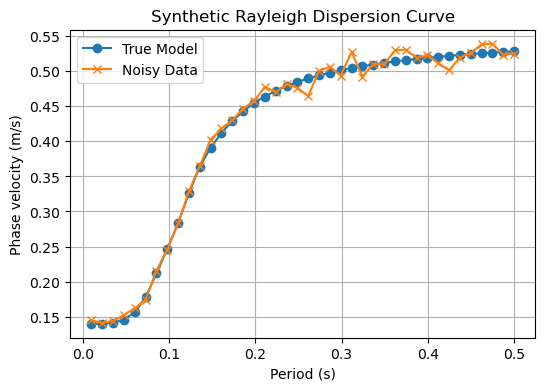

In [91]:
## True model - 2 layers + half-space
# units per disba documentation
# thickness (km)
thickness = [0.005, 0.010, 0]

# s-wave p-wave velocities (km/s)
vs = [.150, .300, 0.600]
vp = [.300, .600, 1.200]
# density (g/cm^3)
rho = [1.8, 1.9, 2.0]
# period[s]
period = np.linspace(0.01, 0.5, 40)

truemodel = forward_model(thickness, vp, vs, rho, period)

np.random.seed(0)

dobs = truemodel.velocity
noise_level = 0.02
dobs_noisy= dobs + noise_level * dobs * np.random.randn(len(dobs))

T = truemodel.period

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Synthetic Rayleigh Dispersion Curve")
plt.grid(True)
plt.legend()
plt.show()

In [70]:
def objective_function(beta, dpred, dobs, vs):
    phi_d = np.sum((dpred - dobs)**2)
    phi_m = np.sum(np.diff(vs)**2)
    phi = phi_d + beta * phi_m

    return phi, phi_d, phi_m

In [71]:
# First Trial
thickness_first = [0.005, 0.010, 0.0] # fix for now - vary vs (perhaps change later)
vs_first = [0.180, 0.250, 0.500]
vp_first = [2*v for v in vs_first] # assume p-waves are 2x s-waves (generally true)
rho_first = [1.8, 1.9, 2.0] # minor impact on model, so assumed constant for now)

In [82]:
beta_first = 0.5

dpred_first = forward_model(thickness_first, vp_first, vs_first, rho_first, period).velocity
obj_first = objective_function(beta_first, dpred_first, dobs_noisy, vs_first)


phi_first, phi_d_first, phi_m_first = objective_function(
    beta_first, dpred_first, dobs_noisy, vs_first
)

In [92]:
## Gradients (small step)
dx = 1e-4

# Vs1
vs_trial1 = [vs_first[0] + dx, vs_first[1], vs_first[2]]
vp_trial1 = [2*v for v in vs_trial1]
dpred1 = forward_model(thickness_first, vp_trial1, vs_trial1, rho_first, period).velocity
phi1, _, _= objective_function(beta_first, dpred1, dobs_noisy, vs_trial1)
grad_vs1 = (phi1 - phi_first) / dx

# Vs2
vs_trial2 = [vs_first[0] +step, vs_first[1], vs_first[2]]
vp_trial2 = [2*v for v in vs_trial2]
dpred2 = forward_model(thickness_first, vp_trial2, vs_trial2, rho_first, period).velocity
phi2, _, _= objective_function(beta_first, dpred2, dobs_noisy, vs_trial2)
grad_vs2 = (phi2 - phi_first) / dx

In [96]:
def step_function(grad_vs1, grad_vs2, step_size, vs):
    #for 2 shear wave velocity system
    vs_new = [
        max(vs_first[0] - step * grad_vs1, 0.05),
        max(vs_first[1] - step * grad_vs2, 0.05),
        vs_first[2]
    ]
    vp_new = [2*v for v in vs_new]
    return vs_new, vp_new

In [106]:
## Step


# # no negative velocities - 0.05 km/s floor
# vs1_new = max(vs_first[0] - step * grad_vs1, 0.05)
# vs2_new = max(vs_first[1] - step * grad_vs2, 0.05)

# vs_trial_new = [vs1_new, vs2_new, 0.6]
# vp_trial_new = [2*v for v in vs_trial_new]
step = 1e-2
vs_trial_new = step_function(grad_vs1, grad_vs2, step, vs_first)[0]
vp_trial_new = step_function(grad_vs1, grad_vs2, step, vs_first)[1]

dpred_new = forward_model(thickness_first, vp_trial_new, vs_trial_new, rho_first, period).velocity
phi_new, phi_d_new, phi_m_new = objective_function(beta_first, dpred_new, dobs_noisy, vs_trial_new)

print("old phi =", phi_first)
print("new phi =", phi_new)
print("new vs =", vs_trial_new)

count = 0

while (phi_new > phi_first) and (count < 7):
    step *= 0.5
    count += 1
    s_trial_new, vp_trial_new = step_function(grad_vs1, grad_vs2, step, vs_current)

    dpred_new = forward_model(thickness_first, vp_trial_new, vs_trial_new, rho_first, period).velocity
    phi_new, phi_d_new, phi_m_new = objective_function(beta_first, dpred_new, dobs_noisy, vs_trial_new)
    print(f"retry {count}: step={step:.3e}, phi={phi_new:.6e}, vs={vs_trial_new}")

if phi_new < phi_first:
    vs = vs_trial_new
    vp = vp_trial_new
    dpred = dpred_new
    phi = phi_new
    print("accepted step")
else:
    print("step failed after 7 step-halving attempts")




old phi = 0.2666698425752809
new phi = 0.24611848220713595
new vs = [np.float64(0.18818137873953017), np.float64(0.2581813787395302), 0.5]
accepted step


In [ ]:
max_iter = 25
tol_phi = 1e-8